#                                  🚚 Supply_Chain_Performance_Optimization

## 📌 Project Overview

This project focuses on analyzing and optimizing supply chain performance using data-driven techniques.

The analysis evaluates key areas such as sales, delivery efficiency, and profitability. Based on these insights, optimization strategies are proposed to improve operational efficiency and reduce delays.

The objective is to transform raw data into actionable business decisions.

## 🎯 Objective

- 📈 Analyze sales and profit performance  
- 🚚 Evaluate delivery efficiency and delays  
- 🌍 Identify high and low performing regions  
- 📊 Understand shipping and customer behavior  
- 🚀 Provide optimization strategies to improve supply chain performance  

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Cleaned Data

In [3]:

df=pd.read_csv("cleaned_supply_chain_data.csv", encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,delivery_days,delay
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,3,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,5,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,4,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,3,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,2,-2


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 51 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Card Id,Product Category Id,Product Price,Product Status,delivery_days,delay
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.0,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35920.541998,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,692.509764,31.851451,141.232550,0.0,3.471856,0.565807
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.423343,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,336.446807,15.640064,139.732492,0.0,1.670471,1.490966
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,19.000000,2.000000,9.990000,0.0,0.000000,-2.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,403.000000,18.000000,50.000000,0.0,2.000000,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,627.000000,29.000000,59.990002,0.0,3.000000,1.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,1004.000000,45.000000,199.990005,0.0,5.000000,1.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,1363.000000,76.000000,1999.989990,0.0,6.000000,4.000000


# Data Preparation

In [5]:
#converting the date into datetime data type.
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

## Key Performance Indicators

In [7]:
total_sales = df["Sales"].sum()
total_profit = df['Order Profit Per Order'].sum()
total_orders = df["Order Id"].nunique()
avg_delivery = df["delivery_days"].mean()

kpi = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Total Orders", "Avg Delivery Time"],
    "Value": [total_sales, total_profit, total_orders, avg_delivery]
})

kpi

,Metric,Value
0,Total Sales,3.678474e+07
1,Total Profit,3.966903e+06
2,Total Orders,6.575200e+04
3,Avg Delivery Time,3.471856e+00


In [11]:
#order by category
Order_By_Category= df['Category Name'].value_counts()
Order_By_Category

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Accessories              1780
Golf Balls               1475
Girls' Apparel           1201
Golf Gloves              1070
Trade-In                  974
Video Games               838
Children's Clothing       652
Women's Clothing          650
Baseball & Softball       632
Hockey                    614
Cameras                   592
Toys                      529
Golf Shoes                524
Pet Supplies              492
Crafts                    484
Garden                    484
DVDs                      483
Computers                 442
Golf Apparel              441
Hunting & Shooting        440
Music                     434
Consumer Electronics      431
Boxing & MMA              

## Performance Analysis

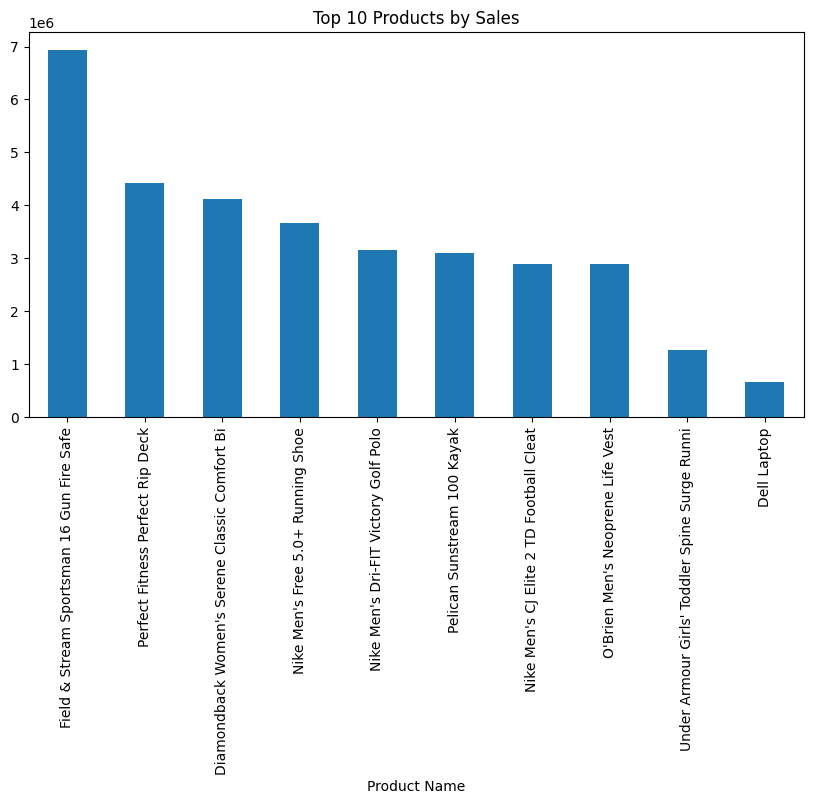

In [10]:
#Top 10 product name.
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.show()

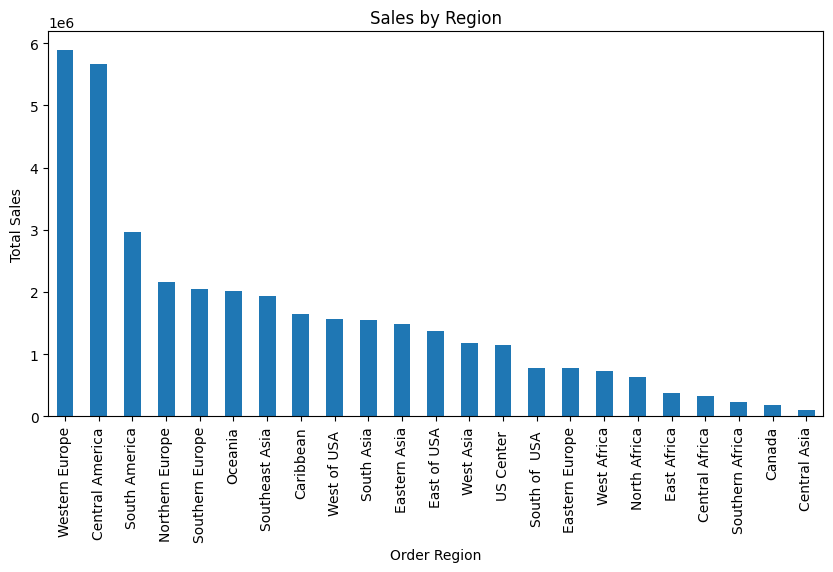

In [ ]:
#Q.Which regions contribute the most to overall sales?
import matplotlib.pyplot as plt
sales_region = df.groupby("Order Region")["Sales"].sum().sort_values(ascending=False)

sales_region.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()

## Sales by Region 

The regional sales analysis shows that some regions contribute significantly more to total sales than others. A few regions clearly dominate in terms of revenue generation, which indicates strong market presence and higher customer demand in those areas. At the same time, some regions show lower sales, which suggests weaker market penetration or operational challenges.
This variation in regional performance highlights the importance of location-based supply chain planning and resource allocation.

### Business Interpretation

High-performing regions should receive more focus in terms of inventory availability, faster shipping, and marketing support to maintain their strong performance. Low-performing regions should be analyzed further to understand whether the issue is related to logistics, pricing, demand, or competition. Improving operations in weaker regions can help increase overall company revenue and expand market reach.

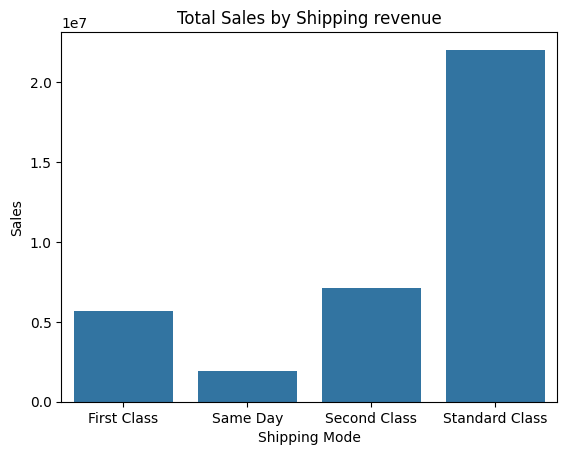

In [ ]:
#Q. Which shipping mode generates the highest revenue?
shipping_sales = df.groupby("Shipping Mode")["Sales"].sum().reset_index()

sns.barplot(x='Shipping Mode', y='Sales', data=shipping_sales)
plt.title("Total Sales by Shipping revenue")
plt.show()

## Shipping Mode Revenue 

The shipping mode analysis shows that Standard Class generates the highest revenue compared to other shipping options. This indicates that most customers prefer standard shipping due to its affordability and reliability. Faster shipping modes like First Class, Second Class, and Same Day contribute less to overall revenue, likely because they are more expensive and used only in urgent situations.
This pattern suggests that the majority of the company's operations depend on standard shipping services.

### Business Interpretation

Since Standard Class is the most commonly used shipping method, the company should focus on improving its efficiency and delivery speed to enhance customer satisfaction. Faster shipping options can be optimized and promoted for premium customers or urgent deliveries to increase their usage. Improving logistics performance across all shipping modes will help reduce delays and strengthen supply chain operations.

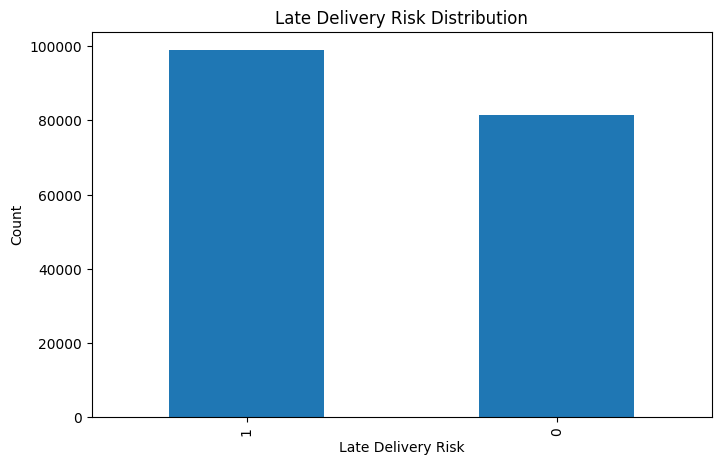

In [6]:
#Q. How frequent are late deliveries in the supply chain?
late_delivery = df["Late_delivery_risk"].value_counts()

late_delivery.plot(kind='bar', figsize=(8,5))
plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Count")

plt.show()

## Late Delivery Risk 

The late delivery risk analysis shows that a significant number of orders are marked as late delivery risk, which indicates delays in the supply chain process. This suggests that delivery operations are not fully optimized and some shipments are taking longer than expected to reach customers.

Late deliveries can negatively impact customer satisfaction, brand reputation, and operational efficiency. Frequent delivery delays may also increase logistics costs and reduce overall business performance.

### Business Interpretation

The company should focus on improving shipping efficiency and reducing delivery delays to enhance customer experience. Optimizing shipping routes, improving warehouse coordination, and monitoring high-delay regions can help reduce late delivery risk. By minimizing delivery delays, the company can strengthen its supply chain performance and maintain customer trust.

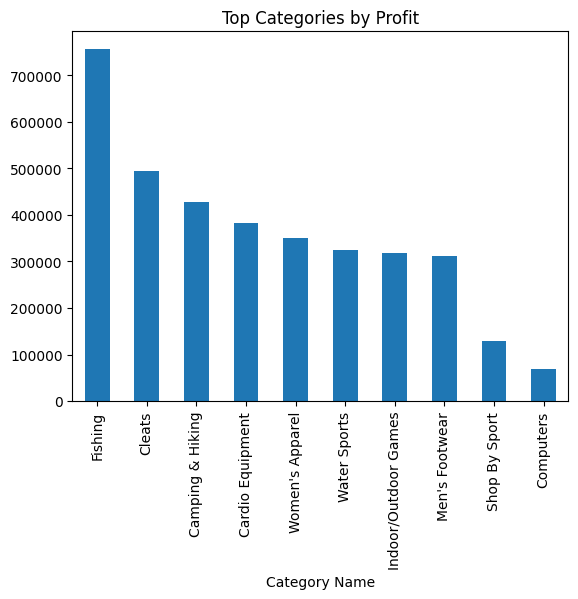

In [12]:
#profit by category
profit_category = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)

profit_category.plot(kind='bar')
plt.title("Top Categories by Profit")
plt.show()

## Profit by Category 

The profit by category analysis shows that some product categories contribute much more to the company’s overall profit than others. Certain categories perform strongly and consistently generate higher profits, which indicates strong demand and efficient cost management in those product lines. At the same time, a few categories generate lower profit, suggesting higher operational costs, lower demand, or pricing challenges.
This variation in profitability highlights the importance of product-level analysis in supply chain and business decision-making.

### Business Interpretation

The company should prioritize high-profit categories by ensuring better inventory availability, efficient delivery, and strong marketing support. Low-profit categories should be reviewed to identify cost reduction opportunities or pricing improvements. By focusing on profitable product lines and optimizing weaker ones, the company can improve overall financial performance and supply chain efficiency.

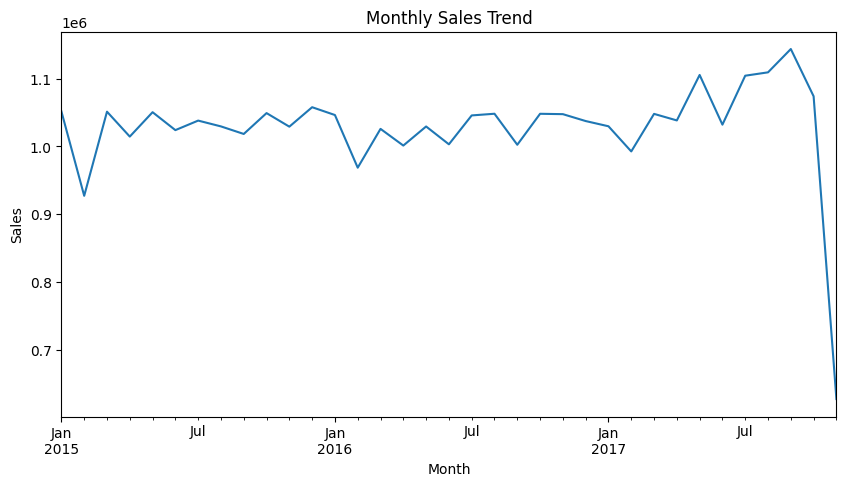

In [15]:
#Q. How do sales change over time? Are there any trends or seasonality?
df['order_month'] = df['order date (DateOrders)'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['Sales'].sum()
monthly_sales = monthly_sales[:-2]

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Monthly Sales Trend 

The monthly sales trend shows that the company maintains a fairly stable sales performance over time, with only small fluctuations across different months. Sales remain consistent throughout the years, which indicates steady demand and well-managed supply chain operations. There are no extreme spikes or sudden drops in most of the timeline, suggesting that the business operates in a stable market environment.

Toward the end of the timeline, there is a noticeable drop in sales, which is likely due to incomplete data for the final months rather than an actual decline in business performance.

### Business Interpretation

Stable monthly sales indicate that the company has a reliable customer base and consistent market demand. This helps in planning inventory, logistics, and workforce efficiently. Since the demand is steady, the company can focus more on improving delivery performance and profit margins instead of worrying about demand fluctuations.

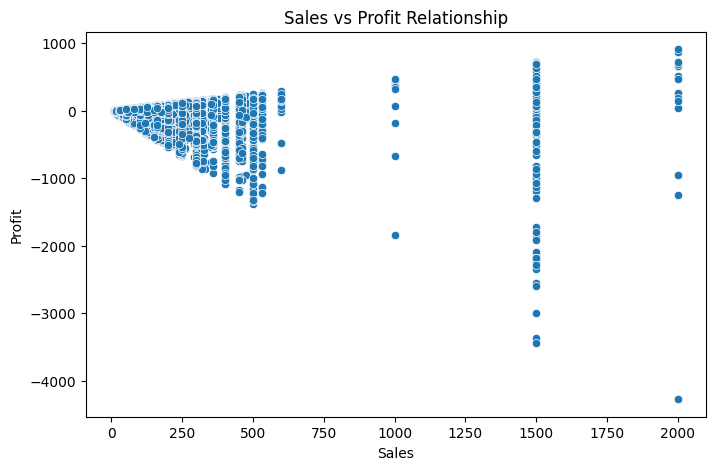

In [ ]:
# #Q. Is higher sales always associated with higher profit?

plt.figure(figsize=(8,5))

sns.scatterplot(x='Sales', y='Order Profit Per Order', data=df)

plt.title("Sales vs Profit Relationship")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

## Sales vs Profit 

The sales vs profit analysis shows that higher sales do not always lead to higher profit. While many orders generate both good sales and profit, there are also several orders where high sales result in low or even negative profit. This indicates that some products or transactions involve high operational or shipping costs, reducing overall profitability.
The scatter distribution suggests that profit is not directly proportional to sales in all cases, which highlights inefficiencies in pricing, logistics, or product cost management.

### Business Interpretation

The company should closely monitor high-sales but low-profit orders to identify cost-related issues. Improving pricing strategies, reducing shipping costs, and optimizing operational expenses can help convert high-sales orders into profitable transactions. By balancing sales and profit, the company can achieve better financial performance and more efficient supply chain operations.

## Correlation Analysis
Understanding relationship between variables

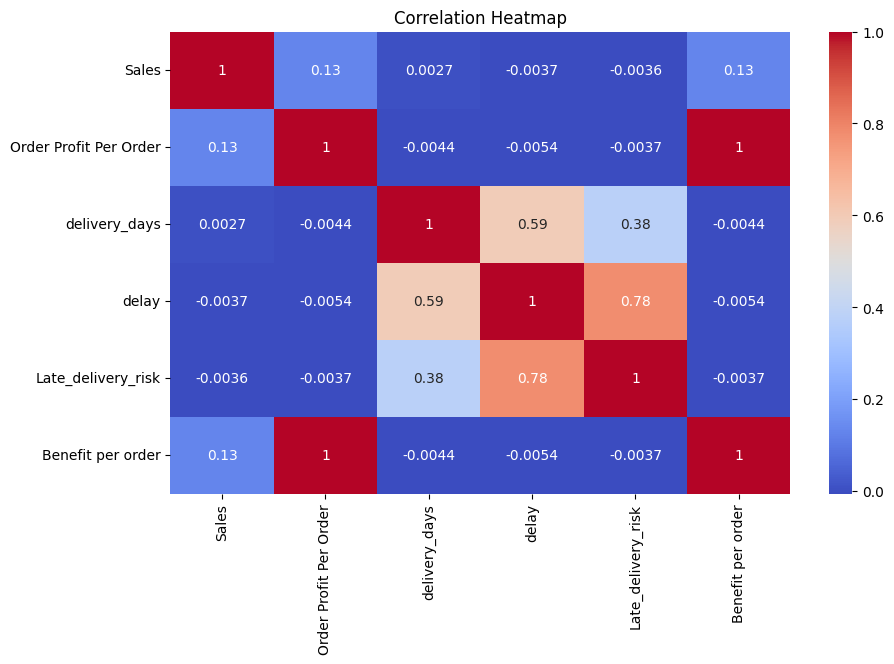

In [ ]:


plt.figure(figsize=(10,6))

corr = df[['Sales',
           'Order Profit Per Order',
           'delivery_days',
           'delay',
           'Late_delivery_risk',
           'Benefit per order']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## Correlation Heatmap 

The correlation heatmap shows the relationship between key numerical variables in the supply chain dataset. Sales and profit show a positive relationship, which means that higher sales generally lead to higher profit, although the relationship is not extremely strong. Delivery days and delay show a strong positive correlation, which is expected because longer delivery time increases the chances of delays.
Late delivery risk is also positively related to delivery days and delay, indicating that inefficient shipping directly increases the risk of late deliveries. Benefit per order and profit show a moderate positive relationship, suggesting that profitable orders contribute to overall business benefit.

### Business Interpretation

The heatmap clearly shows that delivery time plays an important role in supply chain performance. Reducing delivery days can directly reduce delays and late delivery risk. Improving logistics efficiency and shipping speed can lead to better operational performance and customer satisfaction. Understanding these relationships helps the company make data-driven decisions to optimize supply chain operations.

In [18]:
#Q.Which shipping modes are causing the most late deliveries?
late_delivery = df.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False)
late_delivery

Shipping Mode
First Class       0.953225
Second Class      0.766328
Same Day          0.457430
Standard Class    0.380717
Name: Late_delivery_risk, dtype: float64

In [19]:
#Q.Which product categories are most profitable?
profit_category = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)
profit_category

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Name: Order Profit Per Order, dtype: float64

# Optimization Features

In [22]:
#Identifying delay orders.
delayed_orders = df[df['delay'] > 0].shape[0]
delayed_orders

103400

In [ ]:
#Late delivery in percentage.
delay_percentage = round((df['delay'] > 0).mean() * 100,2)
print("Late Delivery Percentage:", delay_percentage)

Late Delivery Percentage: 57.28


In [23]:
#delivery performance label
df['Delivery Performance'] = df['delay'].apply(lambda x: 'On Time' if x <= 0 else 'Delayed')
df['Delivery Performance'].value_counts()

Delivery Performance
Delayed    103400
On Time     77119
Name: count, dtype: int64

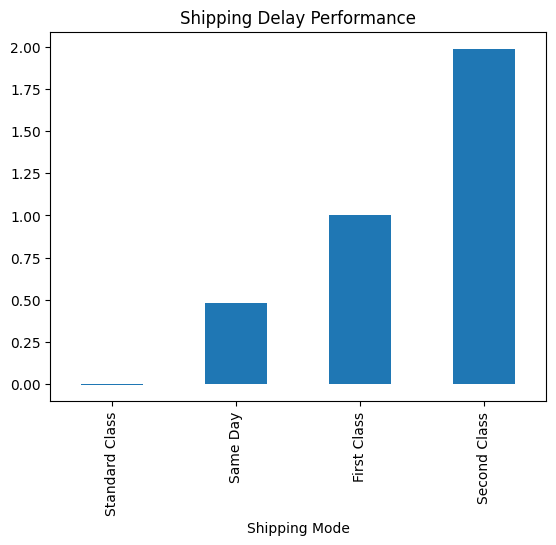

In [16]:
#Shipping Optimization
shipping_perf = df.groupby('Shipping Mode')['delay'].mean().sort_values()

shipping_perf.plot(kind='bar')
plt.title("Shipping Delay Performance")
plt.show()

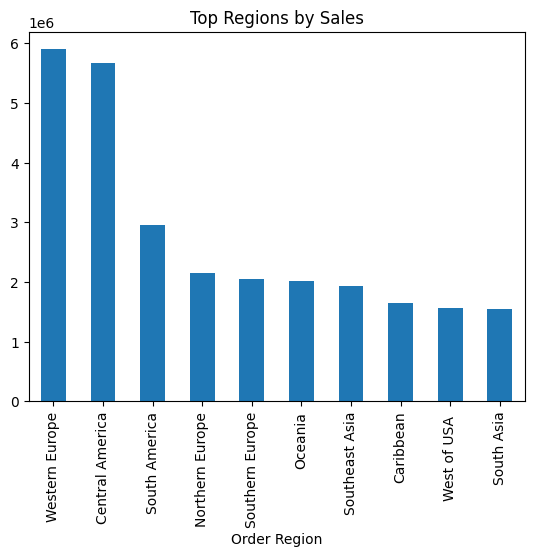

In [17]:
#Region Performance
region_perf = df.groupby('Order Region')['Sales'].sum().sort_values(ascending=False)

region_perf.head(10).plot(kind='bar')
plt.title("Top Regions by Sales")
plt.show()

In [21]:
#Profit Optimization
profit_category = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False)
profit_category.head(10)

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Name: Order Profit Per Order, dtype: float64

In [ ]:
# Identifying High-Sales but Low-Profit Products?

low_profit = df[(df['Sales'] > df['Sales'].mean()) & 
                (df['Order Profit Per Order'] < df['Order Profit Per Order'].mean())]

low_profit[['Product Name', 'Sales', 'Order Profit Per Order']].head(10)

,Product Name,Sales,Order Profit Per Order
1,Smart watch,327.75,-249.089996
2,Smart watch,327.75,-247.779999
5,Smart watch,327.75,18.580000
12,Smart watch,327.75,21.760000
14,Smart watch,327.75,16.389999
15,Smart watch,327.75,-259.579987
16,Smart watch,327.75,-246.360001
23,Smart watch,327.75,17.700001
28,Smart watch,327.75,-17.139999
33,Smart watch,327.75,-97.339996


## ⚠ Problem Identification

- Late deliveries are present  
- Some regions have low sales  
- High sales do not always mean high profit  
- Delivery time varies across shipping modes  

## 🚀 Optimization Strategies

- Use efficient shipping modes to reduce delays  
- Focus on high-performing regions  
- Promote high-profit products  
- Reduce late delivery risk  
- Improve low-performing areas  

## 🧠 Conclusion

This project demonstrates how data analysis can be used to optimize supply chain performance.

By identifying inefficiencies and applying optimization strategies, businesses can improve delivery performance, profitability, and decision-making.